# Efficiency calculation using the analytical TDCR model

## install a stable version of TDCRPy

In [1]:
pip install TDCRPy==2.20.12

Note: you may need to restart the kernel to use updated packages.


## Import the module

In [2]:
import tdcrpy as td
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

## Enter the input parameters

In [3]:
Rad="C-14"                   # radionuclides
pmf_1="1"                   # relatives fractions of the radionulides
kB =1.0e-5                  # Birks constant in cm keV-1
V = 10                      # volume of scintillator in mL
ne = 1000                   # number of discretization steps for the numerical computation of the quenching function

### Efficiency as a function of the free parameter

In [4]:
mode = "eff"                # ask for efficiency calculation
L=np.logspace(-3,2,num=100) # free parameter in keV-1 (photoelectron yield) 

effS, effD, effT = [],[], []
for l in tqdm(L, desc="free parameters ", unit=" iterations"):
  result1 = td.TDCR_model_lib.modelAnalytical(l,0,0,0,0,Rad,kB,V,mode,ne=ne)
  effS.append(result1[0])
  effD.append(result1[1])
  effT.append(result1[2])

free parameters : 100%|██████████| 100/100 [00:00<00:00, 116.92 iterations/s]


### plot of the results

Text(0, 0.5, '$\\epsilon_{D}$')

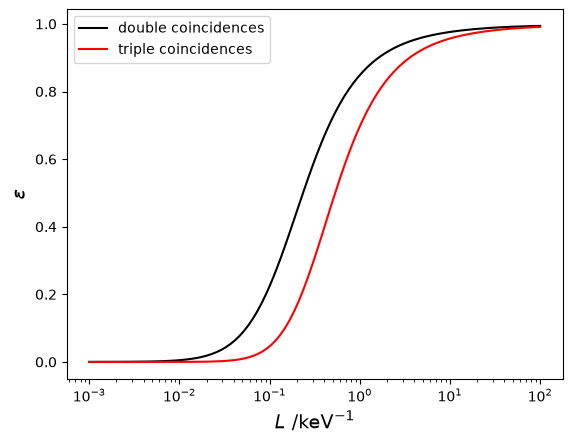

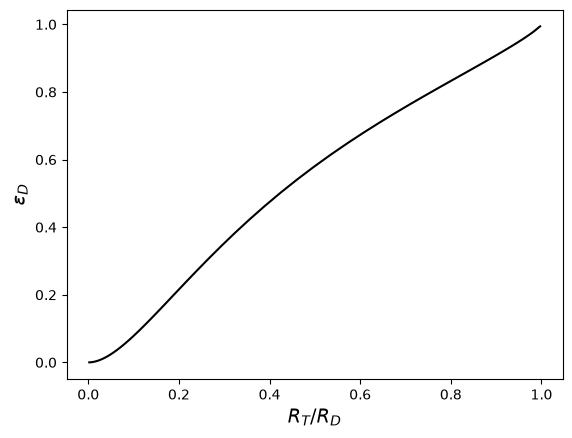

In [5]:
# convert list in array
effS=np.asarray(effS); effT=np.asarray(effT); effD=np.asarray(effD)
# calculate the TDCR parameter
tdcr=effT/effD

plt.figure("efficiency vs free parameter")
plt.clf()
plt.plot(L,effD,"-k",label="double coincidences")
plt.plot(L,effT,"-r",label="triple coincidences")
plt.xscale('log')
plt.xlabel(r'$L$ /keV$^{-1}$', fontsize=14)
plt.ylabel(r'$\epsilon$', fontsize=14)
plt.legend()

plt.figure("efficiency vs TDCR")
plt.clf()
plt.plot(tdcr,effD,"-k")
#plt.xscale('log')
plt.xlabel(r'$R_T/R_D$', fontsize=14)
plt.ylabel(r'$\epsilon_{D}$', fontsize=14)

### Efficiency given the measured TDCR parameters

In [6]:
TD = 0.977667386529166     # TDCR parameter
TAB = 0.992232838598821    # TDCR parameter T/AB
TBC = 0.992343419459002    # TDCR parameter T/BC
TAC = 0.99275350064608     # TDCR parameter T/AC
minL = 0.1                 # minimum light yield (keV-1)
maxL = 50                  # maximum light yield (keV-1)

result2 = td.TDCRPy.effA(TD, Rad, pmf_1, kB, V, Lbounds=[minL, maxL])
print(f"\nResults using a global parameter")
print(f"Global free parameter: {result2[0]}")
print(f"Efficiency of single events: {result2[2]}")
print(f"Efficiency of double coincidence events: {result2[3]}")
print(f"Efficiency of triple coincidence events: {result2[4]}\n")

result3 = td.TDCRPy.effA([TD, TAB, TBC, TAC], Rad, pmf_1, kB, V, Lbounds=[minL, maxL])
print(f"\nResults using 3 free parameters")
print(f"Global free parameter: {result3[0]}")
print(f"Free parameter PMT A: {result3[1][0]}")
print(f"Free parameter PMT B: {result3[1][1]}")
print(f"Free parameter PMT C: {result3[1][2]}")
print(f"Efficiency of single events: {result3[2]}")
print(f"Efficiency of double coincidence events: {result3[3]}")
print(f"Efficiency of triple coincidence events: {result3[4]}")


Results using a global parameter
Global free parameter: 8.68579000127259
Efficiency of single events: 0.9863595816445364
Efficiency of double coincidence events: 0.9736894651230592
Efficiency of triple coincidence events: 0.951944434318587


Results using 3 free parameters
Global free parameter: 8.68579000127259
Free parameter PMT A: 8.638540741913523
Free parameter PMT B: 8.866304655070628
Free parameter PMT C: 8.573200161158347
Efficiency of single events: 0.9863665532301549
Efficiency of double coincidence events: 0.9737028720569711
Efficiency of triple coincidence events: 0.9519634406033773


In [14]:
TD = 0.1    # TDCR parameter
minL = 0.01                 # minimum light yield (keV-1)
maxL = 50                  # maximum light yield (keV-1)

result2 = td.TDCRPy.effA(TD, Rad, pmf_1, kB, V, Lbounds=[minL, maxL])
print(f"\nResults using a global parameter")
print(f"Global free parameter: {result2[0]}")
print(f"Efficiency of single events: {result2[2]}")
print(f"Efficiency of double coincidence events: {result2[3]}")
print(f"Efficiency of triple coincidence events: {result2[4]}\n")


Results using a global parameter
Global free parameter: 0.046964105812007176
Efficiency of single events: 0.3564988734569948
Efficiency of double coincidence events: 0.0783908518206687
Efficiency of triple coincidence events: 0.007839223742065212

